# Part B: Lab Questions

### 1. Generate synthetic datasets for clustering.
### a) Use make_blobs( ) to create a dataset with 3 clusters.
### Note: make_blobs( ) is a function in scikit-learn used to generate synthetic datasets with clusters.
### b) Visualize the dataset using a scatter plot.
### c) Change the number of clusters and observe the results.

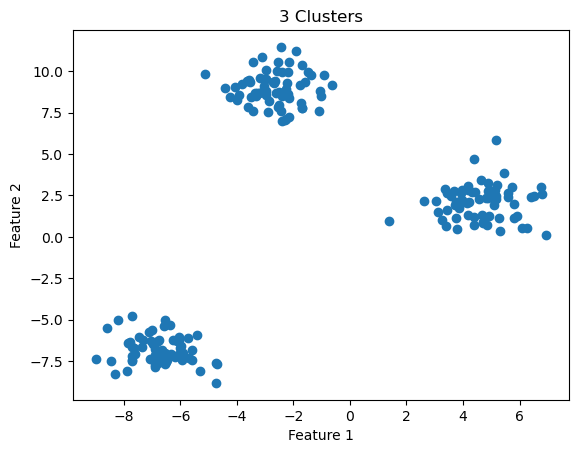

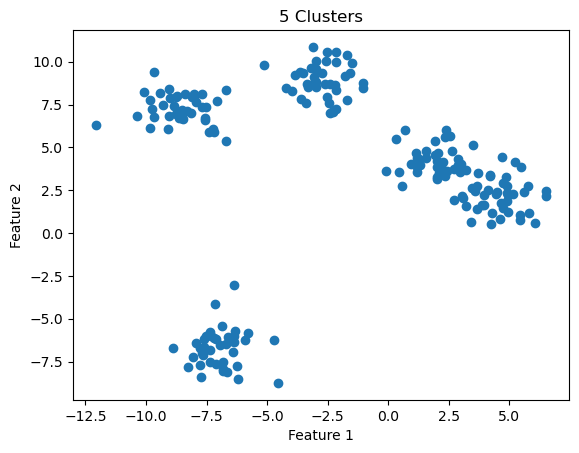

In [9]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# (a) Create dataset with 3 clusters
X, y = make_blobs(n_samples=200, centers=3, random_state=42)

# (b) Visualize dataset
plt.scatter(X[:, 0], X[:, 1])
plt.title("3 Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# (c) Change number of clusters
X2, y2 = make_blobs(n_samples=200, centers=5, random_state=42)

plt.scatter(X2[:, 0], X2[:, 1])
plt.title("5 Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 2. Determine the optimal number of clusters using Elbow Method
### a) Generate a dataset using make_blobs( ).
### b) Apply K-Means for different values of k (k=1 to 9).
### c) Calculate inertia (sum of squared distances).
### d) Plot the Elbow graph.

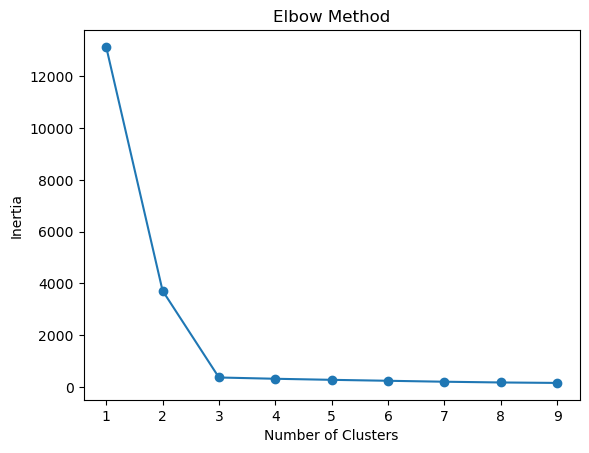

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# (a) Generate dataset
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)

# (b) Apply KMeans for k=1 to 9
wcss = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)

    # (c) Calculate inertia
    wcss.append(km.inertia_)

# (d) Plot Elbow graph
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### 3. Perform clustering using K-Means on a synthetic dataset.
### a) Generate a dataset using make_blobs( ).
### b) Apply the K-Means algorithm.
### c) Change the number of clusters from 2 to 5.
### d) Plot clusters and centroids.
### e) Observe how cluster formation changes.

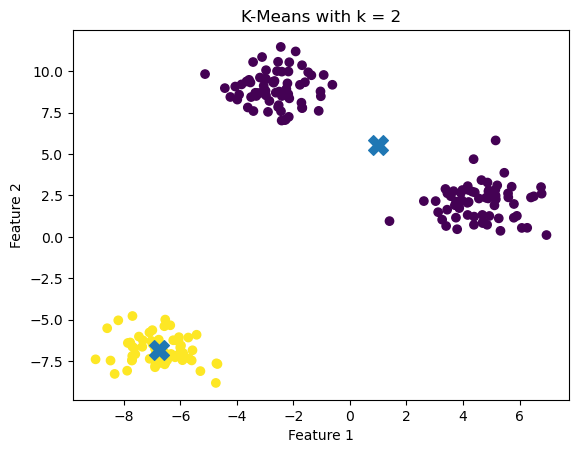

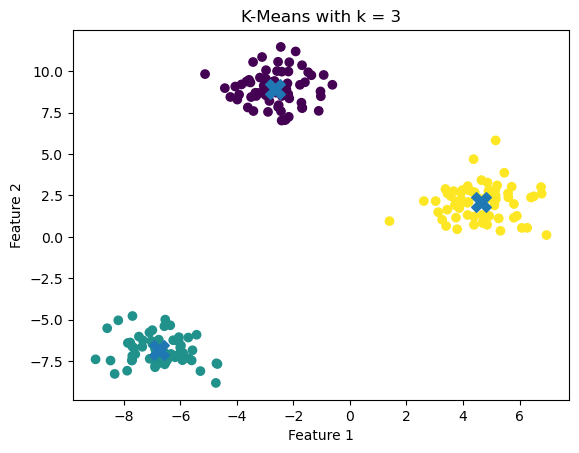

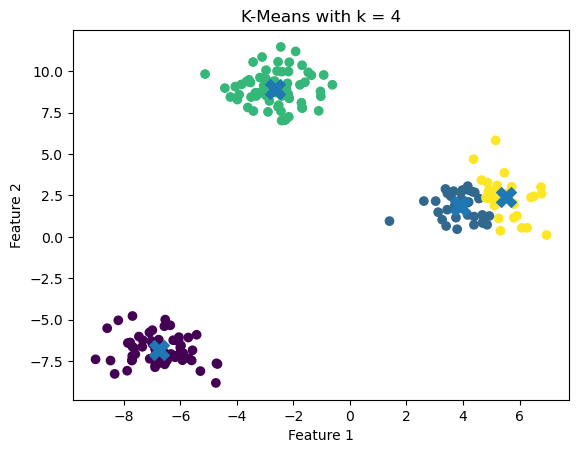

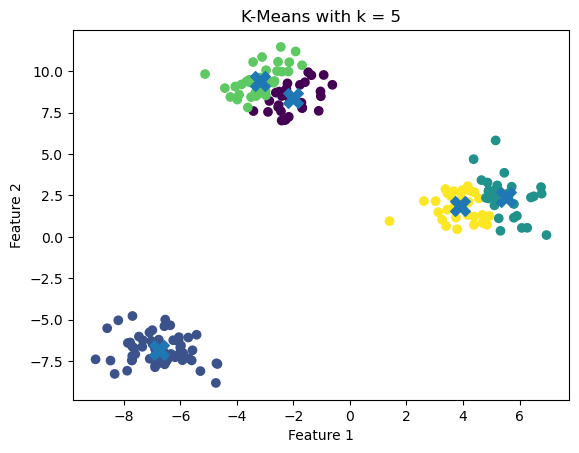

In [11]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# (a) Generate dataset
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)

# (b,c) Apply KMeans for K=2 to 5
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    # (d) Plot clusters and centroids
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.scatter(km.cluster_centers_[:, 0],
                km.cluster_centers_[:, 1],
                marker='X', s=200)
    plt.title(f"K-Means with k = {k}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# (e) Observe visually

### 4. Perform clustering using Hierarchical Clustering on a synthetic dataset.
### a) Generate a dataset using make_blobs( ).
### b) Apply Agglomerative Clustering.
### c) Plot a dendrogram.
### d) Compare results with K-Means clustering.

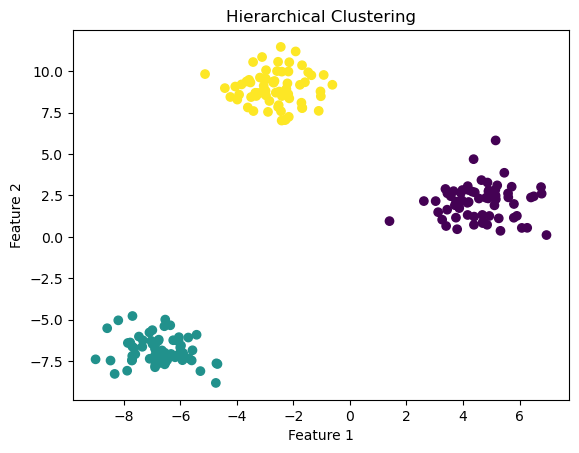

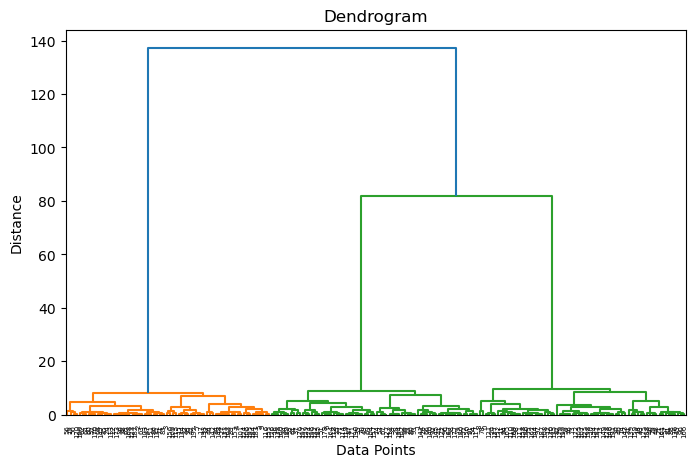

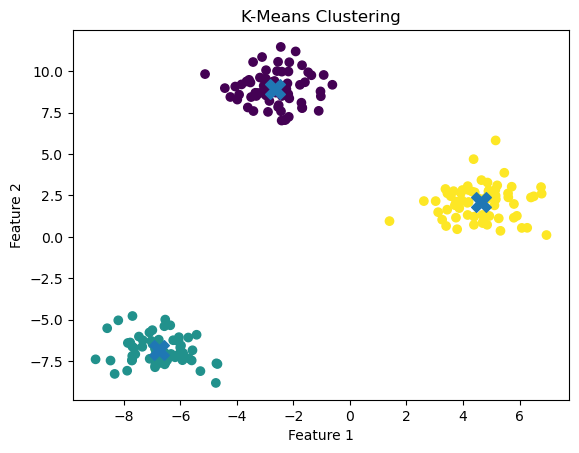

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# (a) Generate dataset
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)

# (b) Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# (c) Dendrogram
Z = linkage(X, method='ward')
plt.figure(figsize=(8, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# (d) Compare with K-Means
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=km_labels)
plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            marker='X', s=200)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### 5. Find patterns using association rules.
### a) Create a small transaction dataset.
### b) Apply the Apriori algorithm.
### c) Calculate support and confidence.
### d) Generate association rules.

In [13]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# (a) Simple Dataset
X = np.array([[1,2],[2,3],[3,4],[-1,-2],[-2,-3],[-3,-4]])
y = np.array([1,1,1,-1,-1,-1])

# (b) Clustering (K-Means)
km = KMeans(n_clusters=2, n_init=10)
clusters = km.fit_predict(X)
print("Cluster Labels:", clusters)

# (c) Perceptron
p = Perceptron()
p.fit(X, y)
pred_p = p.predict(X)

# (d) Neural Network
nn = MLPClassifier(max_iter=500)
nn.fit(X, y)
pred_nn = nn.predict(X)

# (e) Accuracy Comparison
print("Perceptron Accuracy:", accuracy_score(y, pred_p))
print("Neural Network Accuracy:", accuracy_score(y, pred_nn))

# -----------------------------
# (a) Transaction Dataset

transactions = [
    ['Bread', 'Milk'],
    ['Bread', 'Egg'],
    ['Milk', 'Egg'],
    ['Bread', 'Milk', 'Egg']
]

# Convert to DataFrame
df = pd.get_dummies(pd.DataFrame(transactions).stack()).groupby(level=0).sum()

# (b) Apply Apriori
freq_items = apriori(df, min_support=0.5, use_colnames=True)

# (c) Generate Rules
rules = association_rules(freq_items, metric="confidence", min_threshold=0.5)


# (d) Display Results
print("\nFrequent Itemsets:\n", freq_items)
print("\nAssociation Rules:\n", rules)

Cluster Labels: [0 0 0 1 1 1]
Perceptron Accuracy: 1.0
Neural Network Accuracy: 1.0

Frequent Itemsets:
    support       itemsets
0     0.75        (Bread)
1     0.75          (Egg)
2     0.75         (Milk)
3     0.50   (Egg, Bread)
4     0.50  (Bread, Milk)
5     0.50    (Egg, Milk)

Association Rules:
   antecedents consequents  antecedent support  consequent support  support  \
0       (Egg)     (Bread)                0.75                0.75      0.5   
1     (Bread)       (Egg)                0.75                0.75      0.5   
2     (Bread)      (Milk)                0.75                0.75      0.5   
3      (Milk)     (Bread)                0.75                0.75      0.5   
4       (Egg)      (Milk)                0.75                0.75      0.5   
5      (Milk)       (Egg)                0.75                0.75      0.5   

   confidence      lift  representativity  leverage  conviction  \
0    0.666667  0.888889               1.0   -0.0625        0.75   
1    0.6666

/home/iteradmin/.local/lib/python3.9/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


### 6. Implement Artificial Neuron Calculation.
### a) Take input values x1, x2, x3.
### b) Assign weights w1, w2, w3.
### c) Compute neuron output using: y=f(w1x1+w2x2+w3x3+b)
### d) Implement it using each of the following activation function: step function, Sigmoid function, Tanh function, ReLU function

In [14]:
import numpy as np

# (a) Inputs
x1, x2, x3 = 1, 0, 1

# (b) Weights
w1, w2, w3 = 0.5, 0.3, 0.2
b = 0.1

# (c) Weighted sum
y_sum = w1*x1 + w2*x2 + w3*x3 + b

# (d) Activation functions
def step(x): return 1 if x>=0 else 0
def sigmoid(x): return 1/(1+np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return max(0,x)

print("Step:", step(y_sum))
print("Sigmoid:", sigmoid(y_sum))
print("Tanh:", tanh(y_sum))
print("ReLU:", relu(y_sum))

Step: 1
Sigmoid: 0.6899744811276125
Tanh: 0.6640367702678489
ReLU: 0.7999999999999999


### 7. Train a perceptron classifier on a synthetic dataset.
### a) Generate a dataset using make_classification( ).
### b) Train a perceptron classifier.
### c) Plot the decision boundary.
### d) Identify misclassified points and compute accuracy.

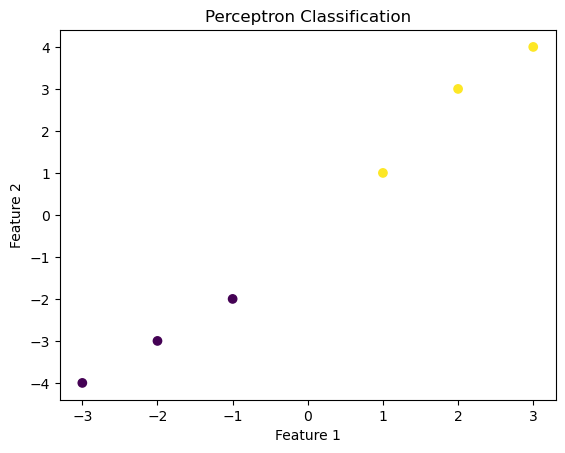

Accuracy: 1.0


In [15]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# (a) Create simple dataset (linearly separable)
X = np.array([[2,3],[3,4],[1,1],[-1,-2],[-2,-3],[-3,-4]])
y = np.array([1,1,1,-1,-1,-1])

# (b) Train perceptron
model = Perceptron()
model.fit(X, y)

# (c) Plot decision boundary (approx using predictions)
pred = model.predict(X)
plt.scatter(X[:,0], X[:,1], c=pred)
plt.title("Perceptron Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# (d) Accuracy
print("Accuracy:", accuracy_score(y, pred))

### 8. Implement a neural network classifier using MLPClassifier
### a) Create a dataset.
### b) Train a neural network classifier.
### c) Change number of hidden layers.
### d) Compare model accuracy.

In [16]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# (a) Create dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])   # XOR pattern

# (b) Train model
model1 = MLPClassifier(hidden_layer_sizes=(4,), max_iter=1000, random_state=42)
model1.fit(X, y)

# (c) Change hidden layers
model2 = MLPClassifier(hidden_layer_sizes=(8,4), max_iter=1000, random_state=42)
model2.fit(X, y)

# (d) Compare accuracy
print("Model 1 Accuracy:", accuracy_score(y, model1.predict(X)))
print("Model 2 Accuracy:", accuracy_score(y, model2.predict(X)))

Model 1 Accuracy: 0.5
Model 2 Accuracy: 0.5


### 9. Design a neural network with one hidden layer and train it using backpropagation to classify two classes.
### a) Create or load a small dataset containing two classes and split it into training and testing sets.
### b) Design the neural network architecture with an input layer, one hidden layer, and an output layer. Initialize weights and biases.
### c) Perform forward propagation to compute the predicted output using an activation function.
### d) Apply the backpropagation algorithm to update weights and train the network, then evaluate the classification accuracy.

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# (a) Create dataset (simple binary classification)
X = np.array([[0,0],[0,1],[1,0],[1,1],[0,2],[2,0]])
y = np.array([0,1,1,0,1,1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# (b) Architecture (1 hidden layer)
model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)

# (c) Train (forward + backprop)
model.fit(X_train, y_train)

# (d) Evaluate
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5


### 10. Complete ML Workflow.
### a) Generate dataset.
### b) Perform clustering to identify patterns.
### c) Train perceptron classifier.
### d) Train neural network classifier.
### e) Compare results.

In [18]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# (a) Create dataset
X = np.array([[1,2],[2,3],[3,4],[-1,-2],[-2,-3],[-3,-4]])
y = np.array([1,1,1,-1,-1,-1])

# (b) Clustering
km = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km.fit_predict(X)
print("Cluster Labels:", clusters)

# (c) Perceptron
p = Perceptron()
p.fit(X, y)
pred_p = p.predict(X)

# (d) Neural Network
nn = MLPClassifier(max_iter=1000, random_state=42)
nn.fit(X, y)
pred_nn = nn.predict(X)

# (e) Compare results
print("Perceptron Accuracy:", accuracy_score(y, pred_p))
print("Neural Network Accuracy:", accuracy_score(y, pred_nn))

Cluster Labels: [0 0 0 1 1 1]
Perceptron Accuracy: 1.0
Neural Network Accuracy: 1.0
